
# Supervised Machine Learning Guide (Beginner Friendly)
## California Housing Dataset

This notebook teaches **Supervised Machine Learning step‑by‑step** using the dataset `housing.csv`.

The workflow follows a **very simple beginner-friendly structure**:

1. Load dataset
2. Perform extensive **Exploratory Data Analysis (EDA)**
3. Prepare data (encoding, cleaning)
4. Train-test split
5. Train ML models **one by one**
6. Evaluate models
7. Compare model performance in a dataframe

Target variable:

**median_house_value**


In [25]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")


# 1. Load Dataset

In [26]:

housing = pd.read_csv("../datasets/housing.csv")

housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [27]:

housing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [28]:

housing.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# 2. Exploratory Data Analysis (EDA)

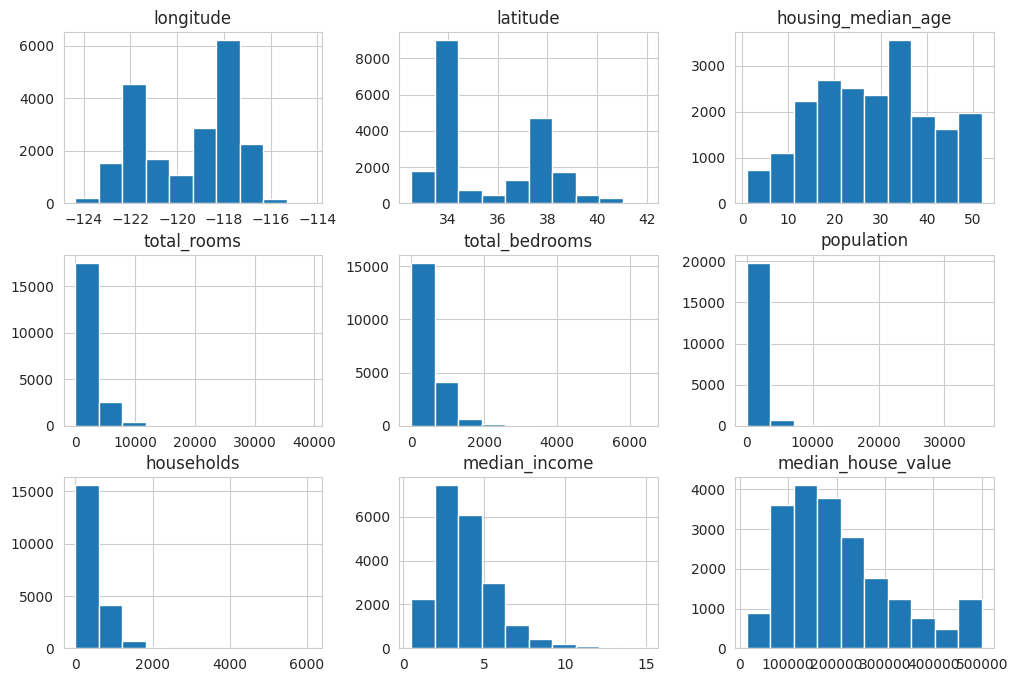

In [29]:

# Histogram of all numeric features
housing.hist(figsize=(12,8))
plt.show()


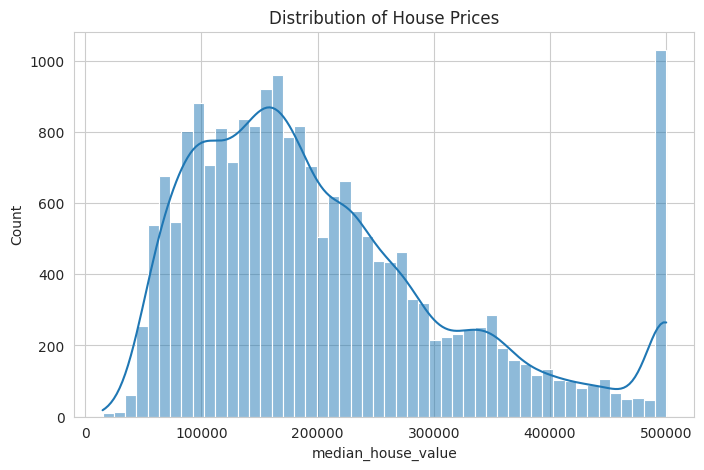

In [30]:

# Distribution of house prices
plt.figure(figsize=(8,5))
sns.histplot(housing["median_house_value"], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.show()


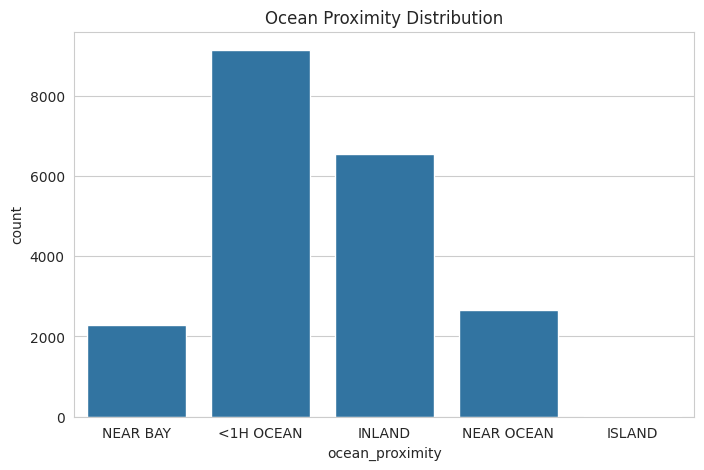

In [31]:

# Count plot for ocean proximity
plt.figure(figsize=(8,5))
sns.countplot(x="ocean_proximity", data=housing)
plt.title("Ocean Proximity Distribution")
plt.show()


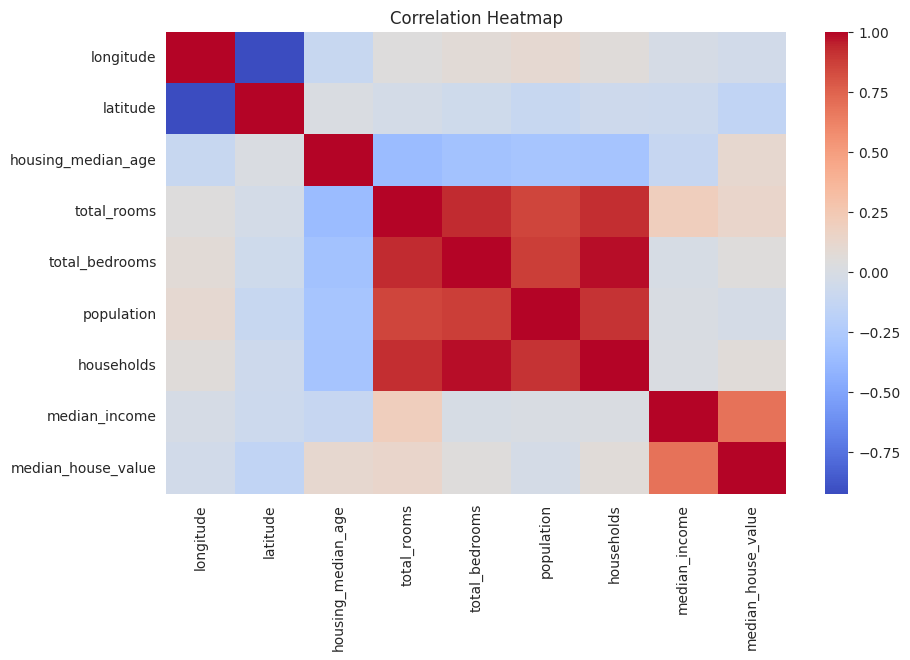

In [32]:

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(housing.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


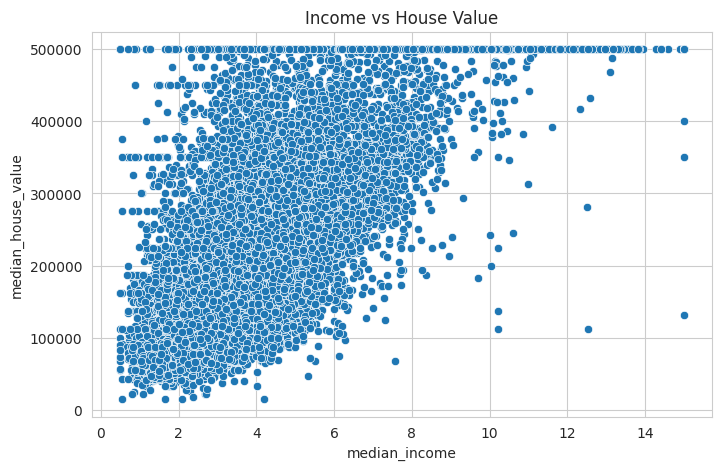

In [33]:

# Scatter plot: income vs house value
plt.figure(figsize=(8,5))
sns.scatterplot(x="median_income", y="median_house_value", data=housing)
plt.title("Income vs House Value")
plt.show()


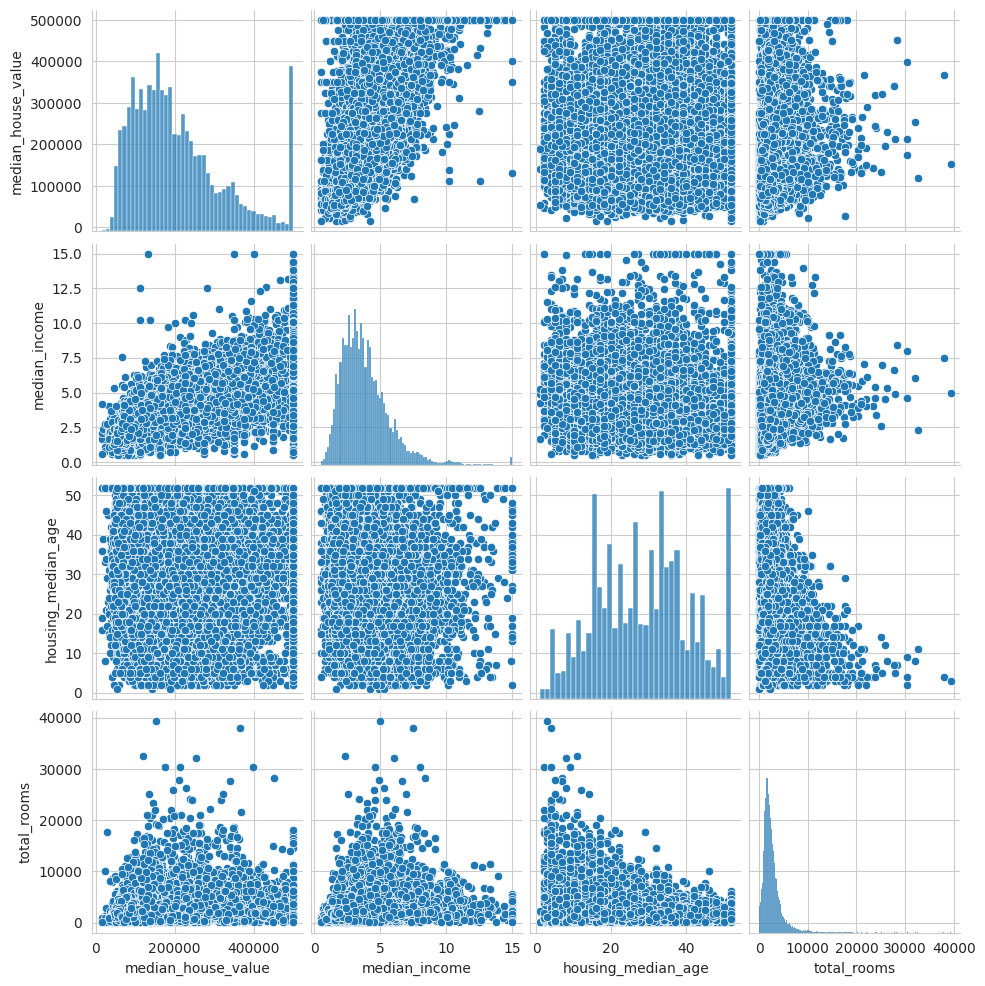

In [34]:

# Pairplot for important features
features = [
    "median_house_value",
    "median_income",
    "housing_median_age",
    "total_rooms"
]

sns.pairplot(housing[features])



### Key Findings from EDA

Typical insights you may observe:

• Median income strongly correlates with house value  
• Housing price distribution is skewed  
• Ocean proximity influences property prices  
• Some features contain large ranges and may require scaling


# 3. Data Preparation

In [35]:

# Check missing values
housing.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [36]:

# Fill missing values in total_bedrooms using median
housing["total_bedrooms"] = housing["total_bedrooms"].fillna(housing["total_bedrooms"].median())


In [37]:

# Convert categorical variable using one-hot encoding
housing = pd.get_dummies(housing, columns=["ocean_proximity"])


# 4. Train Test Split

In [38]:

X = housing.drop("median_house_value", axis=1)
y = housing["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 5. Train Models One by One

In [39]:

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))
linear_r2 = r2_score(y_test, linear_preds)


In [40]:

from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor()

tree_model.fit(X_train, y_train)

tree_preds = tree_model.predict(X_test)

tree_rmse = np.sqrt(mean_squared_error(y_test, tree_preds))
tree_r2 = r2_score(y_test, tree_preds)


In [41]:

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)


In [42]:

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor()

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2 = r2_score(y_test, gb_preds)


In [43]:

from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor()

knn_model.fit(X_train, y_train)

knn_preds = knn_model.predict(X_test)

knn_rmse = np.sqrt(mean_squared_error(y_test, knn_preds))
knn_r2 = r2_score(y_test, knn_preds)


In [44]:

from sklearn.svm import SVR

svr_model = SVR(kernel="rbf")

svr_model.fit(X_train, y_train)

svr_preds = svr_model.predict(X_test)

svr_rmse = np.sqrt(mean_squared_error(y_test, svr_preds))
svr_r2 = r2_score(y_test, svr_preds)


# 6. Compare Model Results

In [45]:

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "SVR"
    ],
    
    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse,
        gb_rmse,
        knn_rmse,
        svr_rmse
    ],
    
    "R2 Score": [
        linear_r2,
        tree_r2,
        rf_r2,
        gb_r2,
        knn_r2,
        svr_r2
    ]
})

results.sort_values("RMSE")


,Model,RMSE,R2 Score
2,Random Forest,48998.807646,0.816784
3,Gradient Boosting,55882.186428,0.761691
1,Decision Tree,69754.549035,0.628689
0,Linear Regression,70060.521845,0.625424
4,KNN,100689.342007,0.226322
5,SVR,117229.247651,-0.048733



# Conclusion

Lower **RMSE** indicates better model performance.

Common outcomes:

• Random Forest performs very well  
• Gradient Boosting also performs strongly  
• Linear Regression acts as a simple baseline model


# Sklearn pipeline

In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load data
housing = pd.read_csv("../datasets/housing.csv")

# Features and target
X = housing.drop("median_house_value", axis=1)
y = housing["median_house_value"]

# Identify column types
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

# Numeric pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols)
])

# Full pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Hyperparameter search space
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

# Random Search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=4,
    cv=2,
    scoring="neg_mean_squared_error",
    n_jobs=1,
    verbose=2,
    random_state=42
)

# Train model
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", random_search.best_params_)
print("RMSE:", rmse)
print("R2 Score:", r2)

Fitting 2 folds for each of 4 candidates, totalling 8 fits


[CV] END model__max_depth=None, model__max_features=None, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=300; total time=   9.0s
[CV] END model__max_depth=None, model__max_features=None, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=300; total time=   9.0s
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=100; total time=   0.9s
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=100; total time=   0.9s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time=   3.1s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time=   3.0s
[CV] END model__max_depth=None, model__max_features=None, model__m